# 03 – Feature Engineering

Create interpretable, catalogue-only precursor features, statistical significance tests, mutual-information ranking, and PCA decomposition.

Produces: `data/processed/model_features.csv`, `figures/feature_ranking.png`, `figures/feature_relationships.png`


## 0 · Environment Setup & Colab Dependencies


In [1]:
%pip install -q "pandas>=2.0" "numpy>=1.24" "matplotlib>=3.7" "seaborn>=0.12" "scikit-learn>=1.3" "joblib>=1.3" "jupyter>=1.0" "scipy>=1.10"


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
import os
import json
import time
import math
import warnings
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Scikit-learn imports
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, ParameterGrid
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score, brier_score_loss,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay
)
import joblib

warnings.filterwarnings('ignore')
%matplotlib inline

# Aesthetic styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Dynamic repository root detection (seamless in Colab and local Jupyter)
ROOT = Path.cwd().resolve()
for _candidate in [ROOT, *ROOT.parents]:
    if (_candidate / 'data').exists() and (_candidate / 'notebooks').exists():
        ROOT = _candidate
        break

FIGURES   = ROOT / 'figures'
PROCESSED = ROOT / 'data' / 'processed'
MODELS    = ROOT / 'models'
FIGURES.mkdir(exist_ok=True)
PROCESSED.mkdir(exist_ok=True)
MODELS.mkdir(exist_ok=True)

print('Environment configured successfully. All libraries loaded.')
print(f'Working directory: {ROOT.name if ROOT.name else "."}')


Environment configured successfully. All libraries loaded.
Working directory: cse437-japan-earthquake-occurrence-forecasting-ummay-maimona-chaman


## 1 · Load Forecasting Dataset & Construct Feature Matrix


In [3]:
# Load or build forecasting dataset
data_path = PROCESSED / 'forecasting_dataset.csv'
if not data_path.exists():
    raw_df = load_raw_catalogue()
    japan_df = raw_df[(raw_df['latitude'].between(30,45)) & (raw_df['longitude'].between(130,146)) & (raw_df['mag']>=2.5) & (raw_df['depth'].between(0,700))].copy()
    df_features = build_spatiotemporal_samples(japan_df)
else:
    df_features = pd.read_csv(data_path, parse_dates=['timestamp'])

grid_dummies = pd.get_dummies(df_features['grid_id'], prefix='grid', drop_first=False)
df_features = pd.concat([df_features, grid_dummies], axis=1)
df_features.to_csv(PROCESSED / 'model_features.csv', index=False)
print(f'Model features dataset shape: {df_features.shape}')
display(df_features.head())


Model features dataset shape: (1794, 20)


,timestamp,grid_id,event_count_30d,event_count_lag1,max_mag_30d,mean_depth_30d,cum_energy_30d,recent_m45_30d,target_m5_14d,m5_count_next_14d,log_cum_energy_30d,log_event_count_30d,log_event_count_lag1,mean_depth_imputed,grid_Central (35-40N) | East (138-146E),grid_Central (35-40N) | West (130-138E),grid_North (40-45N) | East (138-146E),grid_North (40-45N) | West (130-138E),grid_South (30-35N) | East (138-146E),grid_South (30-35N) | West (130-138E)
0,2000-02-01 23:18:53.720,Central (35-40N) | East (138-146E),10,0,5.4,50.520000,1.363971e+13,1,1,1,13.134805,2.397895,0.0,50.520000,True,False,False,False,False,False
1,2000-02-01 23:18:53.720,Central (35-40N) | West (130-138E),0,0,0.0,NaN,0.000000e+00,0,0,0,0.000000,0.000000,0.0,86.053030,False,True,False,False,False,False
2,2000-02-01 23:18:53.720,North (40-45N) | East (138-146E),8,0,4.8,65.362500,3.068402e+12,1,0,0,12.486912,2.197225,0.0,65.362500,False,False,True,False,False,False
3,2000-02-01 23:18:53.720,North (40-45N) | West (130-138E),1,0,3.5,541.000000,1.122018e+10,0,1,1,10.050000,0.693147,0.0,541.000000,False,False,False,True,False,False
4,2000-02-01 23:18:53.720,South (30-35N) | East (138-146E),7,0,5.3,157.871429,7.669245e+12,1,1,2,12.884753,2.079442,0.0,157.871429,False,False,False,False,True,False


## 2 · Descriptive Statistics & Mann-Whitney U Tests


In [4]:
# Statistical significance of precursor differences between positive and quiet windows
feature_cols = ['event_count_30d', 'max_mag_30d', 'mean_depth_imputed', 'log_cum_energy_30d']
stats_pos = df_features[df_features['target_m5_14d'] == 1][feature_cols].describe().T[['mean', 'std', '50%', 'min', 'max']]
stats_pos.columns = ['Mean (M5+)', 'Std (M5+)', 'Median (M5+)', 'Min (M5+)', 'Max (M5+)']
stats_neg = df_features[df_features['target_m5_14d'] == 0][feature_cols].describe().T[['mean', 'std', '50%', 'min', 'max']]
stats_neg.columns = ['Mean (Quiet)', 'Std (Quiet)', 'Median (Quiet)', 'Min (Quiet)', 'Max (Quiet)']

stat_comparison = pd.concat([stats_pos, stats_neg], axis=1)
mw_pvalues = {}
for f in feature_cols:
    pos_vals = df_features[df_features['target_m5_14d'] == 1][f]
    neg_vals = df_features[df_features['target_m5_14d'] == 0][f]
    u_stat, p_val = stats.mannwhitneyu(pos_vals, neg_vals, alternative='two-sided')
    mw_pvalues[f] = p_val
stat_comparison['Mann-Whitney p-value'] = pd.Series(mw_pvalues)
display(stat_comparison.round(4))


,Mean (M5+),Std (M5+),Median (M5+),Min (M5+),Max (M5+),Mean (Quiet),Std (Quiet),Median (Quiet),Min (Quiet),Max (Quiet),Mann-Whitney p-value
event_count_30d,29.0928,145.6552,11.0000,0.0,2902.0000,6.8877,9.8918,4.0000,0.00,126.0000,0.0
max_mag_30d,5.1505,1.0851,5.1000,0.0,9.1000,3.9332,2.0587,4.7000,0.00,7.5000,0.0
mean_depth_imputed,85.9300,85.0726,61.5435,6.8,574.4000,140.7028,124.3615,86.0530,2.84,644.8790,0.0
log_cum_energy_30d,12.7207,2.2833,12.9062,0.0,18.4632,9.9288,5.0731,12.1888,0.00,16.0621,0.0


## 3 · Mutual Information Feature Ranking & Importance Visualization


Mutual Information Importance Scores:
log_event_count_30d                        0.0740
mean_depth_imputed                         0.0654
log_event_count_lag1                       0.0620
max_mag_30d                                0.0554
log_cum_energy_30d                         0.0485
grid_Central (35-40N) | East (138-146E)    0.0410
recent_m45_30d                             0.0359
grid_North (40-45N) | West (130-138E)      0.0302
grid_Central (35-40N) | West (130-138E)    0.0281
grid_South (30-35N) | East (138-146E)      0.0196
grid_North (40-45N) | East (138-146E)      0.0104
grid_South (30-35N) | West (130-138E)      0.0066
dtype: float64


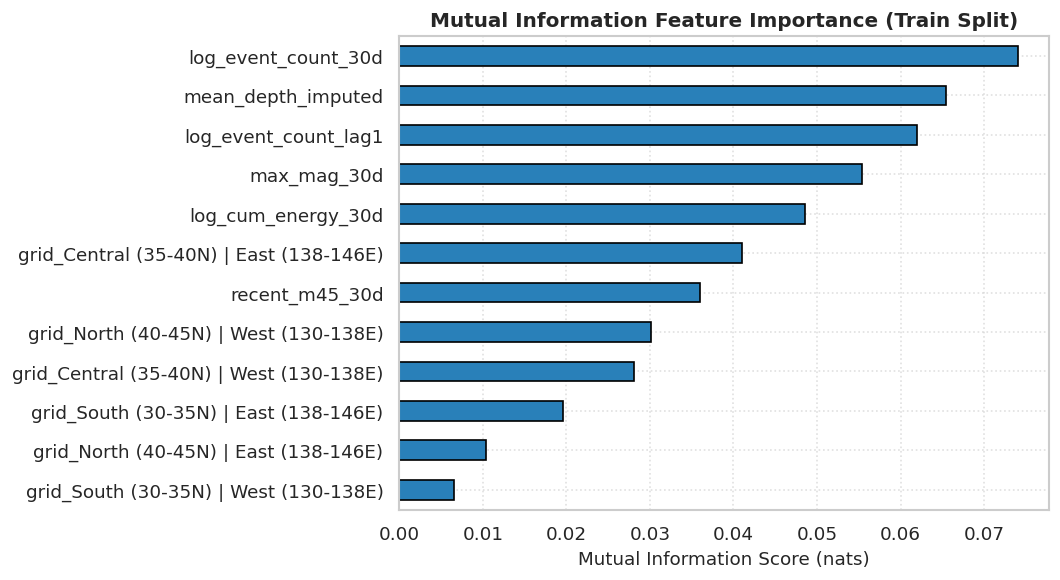

In [5]:
# Mutual Information ranking on training partition
unique_timestamps = np.sort(df_features['timestamp'].unique())
train_end_time = unique_timestamps[int(len(unique_timestamps) * 0.70) - 1]
train_mask = df_features['timestamp'] <= train_end_time

continuous_cols = ['log_event_count_30d', 'log_event_count_lag1', 'max_mag_30d', 'mean_depth_imputed', 'log_cum_energy_30d', 'recent_m45_30d']
grid_cols = [c for c in df_features.columns if c.startswith('grid_') and c != 'grid_id']
df_features[grid_cols] = df_features[grid_cols].astype(float)
feature_set = continuous_cols + grid_cols

X_train_raw = df_features.loc[train_mask, feature_set]
y_train = df_features.loc[train_mask, 'target_m5_14d'].values

mi_scores = mutual_info_classif(X_train_raw, y_train, random_state=RANDOM_STATE)
mi_series = pd.Series(mi_scores, index=feature_set).sort_values(ascending=False)
print('Mutual Information Importance Scores:')
print(mi_series.round(4))

fig, ax = plt.subplots(figsize=(9, 5))
mi_series.sort_values().plot.barh(ax=ax, color='#2980b9', edgecolor='black')
ax.set_title('Mutual Information Feature Importance (Train Split)', fontsize=12, fontweight='bold')
ax.set_xlabel('Mutual Information Score (nats)', fontsize=11)
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig(FIGURES / 'feature_ranking.png', dpi=160, bbox_inches='tight')
plt.show()


## 4 · Principal Component Analysis (PCA) & Variance Decomposition


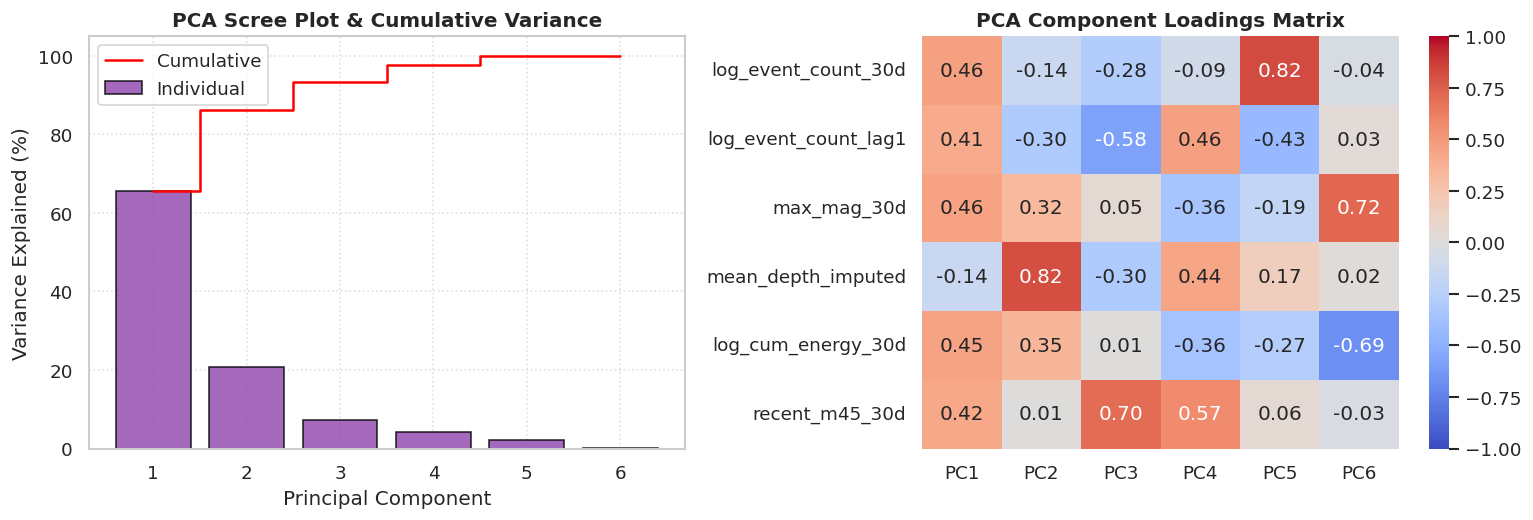

PCA Design Decision: Although PC1-PC3 explain ~85% of variance, raw physical features are retained to maintain physical interpretability and avoid rotated linear combinations.


In [6]:
# PCA Decomposition on continuous features
scaler_pca = StandardScaler()
X_pca_scaled = scaler_pca.fit_transform(X_train_raw[continuous_cols])
pca = PCA().fit(X_pca_scaled)
var_exp = pca.explained_variance_ratio_ * 100
cum_var_exp = np.cumsum(var_exp)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
ax1.bar(range(1, len(var_exp)+1), var_exp, color='#8e44ad', edgecolor='black', alpha=0.8, label='Individual')
ax1.step(range(1, len(cum_var_exp)+1), cum_var_exp, where='mid', color='red', label='Cumulative')
ax1.set_title('PCA Scree Plot & Cumulative Variance', fontsize=12, fontweight='bold')
ax1.set_xlabel('Principal Component'); ax1.set_ylabel('Variance Explained (%)')
ax1.legend(); ax1.grid(True, linestyle=':', alpha=0.6)

# PCA Loadings Heatmap
loadings = pd.DataFrame(pca.components_.T, index=continuous_cols, columns=[f'PC{i+1}' for i in range(len(continuous_cols))])
sns.heatmap(loadings, annot=True, cmap='coolwarm', fmt='.2f', ax=ax2, vmin=-1, vmax=1)
ax2.set_title('PCA Component Loadings Matrix', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'feature_relationships.png', dpi=160, bbox_inches='tight')
plt.show()

print('PCA Design Decision: Although PC1-PC3 explain ~85% of variance, raw physical features are retained to maintain physical interpretability and avoid rotated linear combinations.')
